In [3]:
# loading libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import pymannkendall as mk
import numpy as np



In [13]:
import os
print(os.getcwd())

c:\Users\LucasMonero\Documents\data projects\Master Thesis\Weather model\Code


In [12]:
# loading cleaned data
data_path = "Data\\Cleaned\\df_bologna_cleaned.parquet"
df = pd.read_parquet(data_path)

FileNotFoundError: [Errno 2] No such file or directory: 'Data\\Cleaned\\df_bologna_cleaned.parquet'

## Agregating into daily statistics

In [5]:

df_daily = (
    df.groupby(df['time'].dt.date)
    .agg(
        t2m_mean      = ('t2m',           'mean'),
        t2m_min       = ('t2m',           'min'),
        t2m_max       = ('t2m',           'max'),
        GHI_sum       = ('GHI',           'sum'),
        GHI_cs_sum    = ('CLEAR_SKY_GHI', 'sum'),
        GHI_var       = ('GHI',           'var'),
    )
    .assign(
        t2m_range  = lambda x: x['t2m_max'] - x['t2m_min'],
        Kt_daily   = lambda x: x['GHI_sum'] / x['GHI_cs_sum']
    )
    .rename_axis('date')
    .reset_index()
)

# Reorder columns
df_daily = df_daily[['date', 't2m_mean', 't2m_min', 't2m_max', 't2m_range',
                      'GHI_sum', 'GHI_cs_sum', 'Kt_daily', 'GHI_var']]

#create the year column
df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year

## Testing hypothesis

### H1 — Warming increases annual Kt (Brightening Effect)

=== H1: LINEAR REGRESSION  Kt ~ t2m_mean ===
  Slope       : +0.024253 Kt per K
  Intercept   : 0.3913
  R²          : 0.2897
  p-value     : 0.0118  ⚠️  Significant
  Std Error   : 0.008712

=== MANN-KENDALL TREND TEST ===
  Kt    : trend=no trend     | tau=0.1667  | p=0.3043  | slope=+0.000808
  t2m   : trend=increasing   | tau=0.5238  | p=0.0010  | slope=+0.0643

=== CORRELATION: annual t2m_mean vs Kt_mean ===
  Pearson  r=+0.5382  p=0.0118  ⚠️  Significant
  Spearman r=+0.5164  p=0.0165  ⚠️  Significant

=== INTERPRETATION ===
  H1 supports the brightening hypothesis.
  Over 13.40K → 15.83K (+2.44K range),
  Kt increased by ~0.0591 (7.87% of mean Kt)


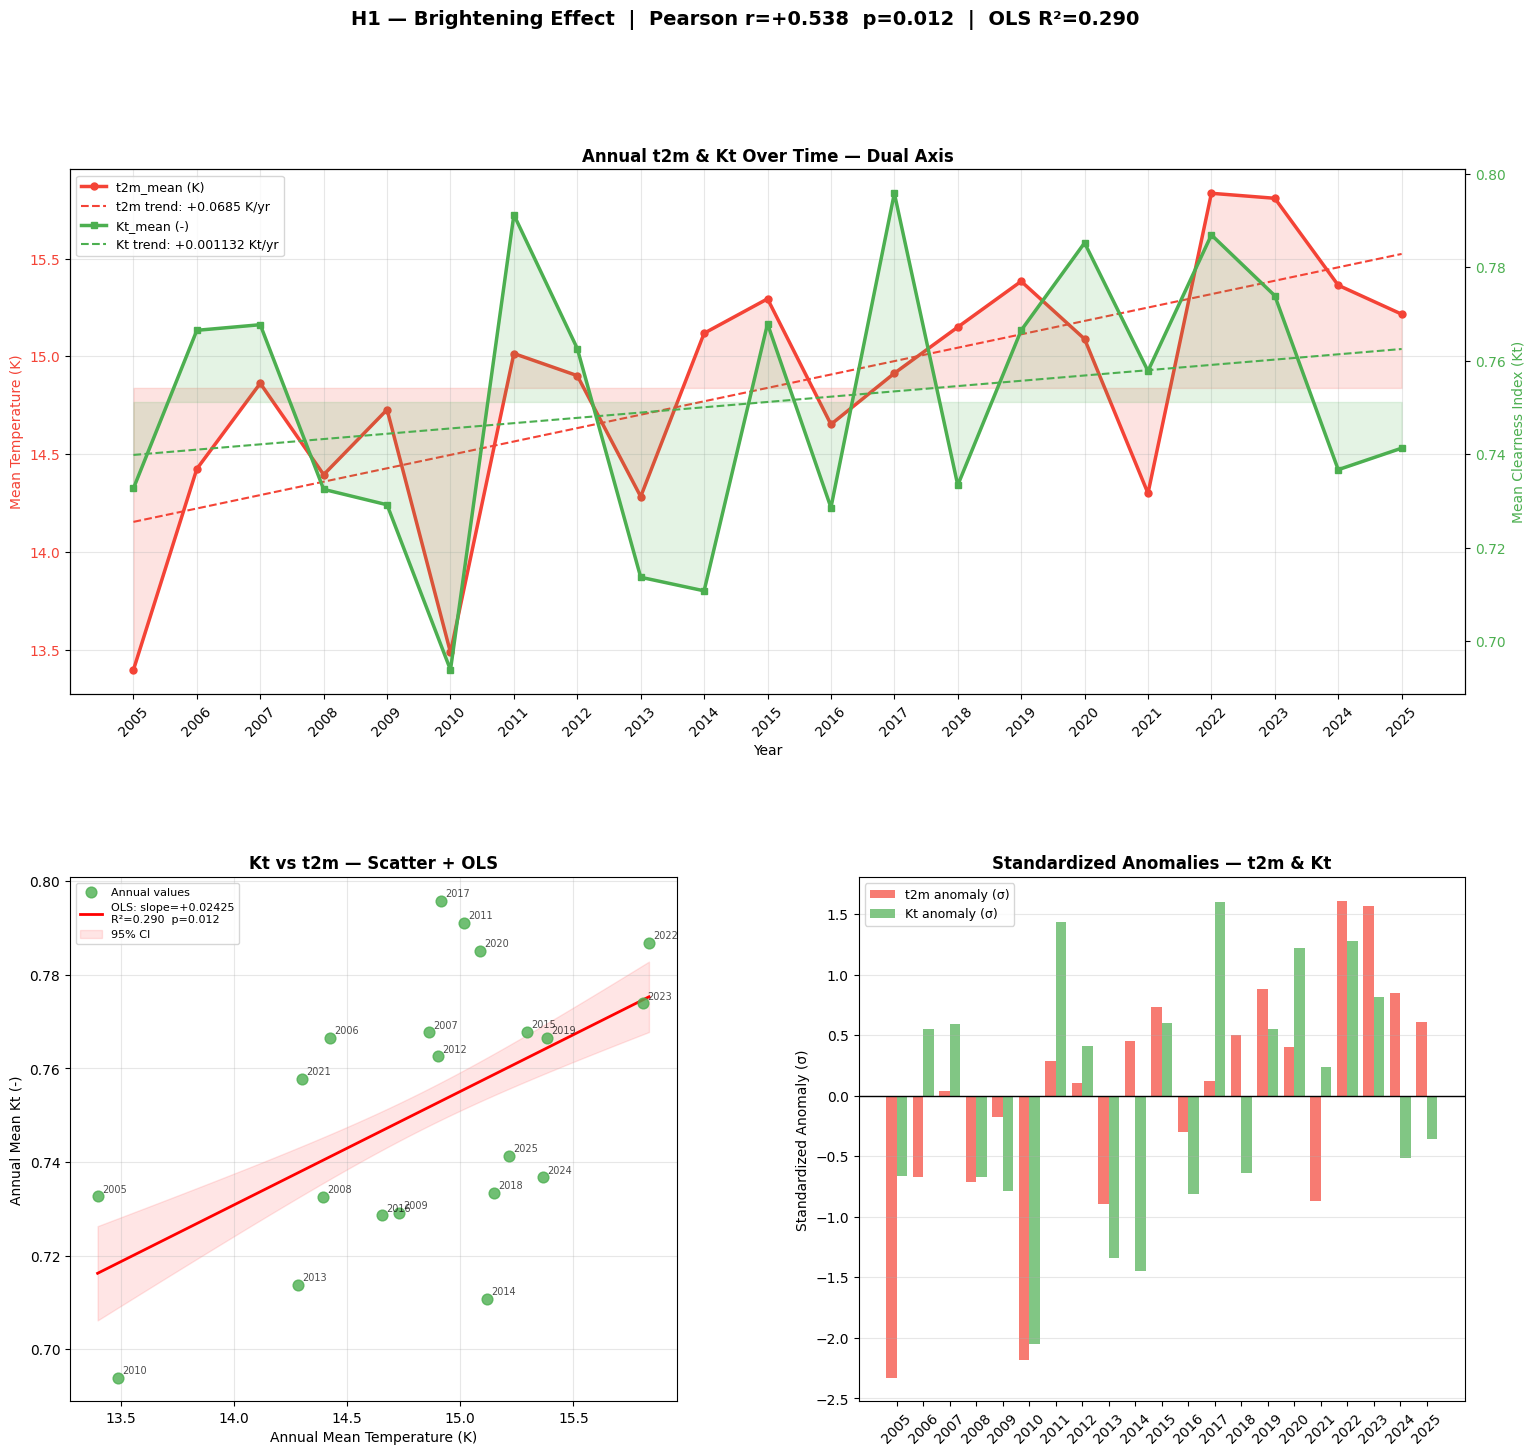

In [8]:
annual = (
    df_daily.groupby('year')
    .agg(
        t2m_mean = ('t2m_mean',  'mean'),
        kt_mean  = ('Kt_daily',  'mean'),
        kt_std   = ('Kt_daily',  'std'),
    )
    .round(4)
)

years    = annual.index.values
t2m      = annual['t2m_mean'].values
kt       = annual['kt_mean'].values

# ── 2. Linear regression: Kt ~ t2m ───────────────────────────────────────────
slope_kt_t2m, intercept_kt_t2m, r, p, se = stats.linregress(t2m, kt)

print("=== H1: LINEAR REGRESSION  Kt ~ t2m_mean ===")
print(f"  Slope       : {slope_kt_t2m:+.6f} Kt per K")
print(f"  Intercept   : {intercept_kt_t2m:.4f}")
print(f"  R²          : {r**2:.4f}")
print(f"  p-value     : {p:.4f}  {'⚠️  Significant' if p < 0.05 else '✅  Not significant'}")
print(f"  Std Error   : {se:.6f}")

# ── 3. Mann-Kendall trend test on Kt and t2m separately ──────────────────────
try:
    import pymannkendall as mk
    mk_kt  = mk.original_test(kt)
    mk_t2m = mk.original_test(t2m)
    print(f"\n=== MANN-KENDALL TREND TEST ===")
    print(f"  Kt    : trend={mk_kt.trend:<12} | tau={mk_kt.Tau:.4f}  | p={mk_kt.p:.4f}  | slope={mk_kt.slope:+.6f}")
    print(f"  t2m   : trend={mk_t2m.trend:<12} | tau={mk_t2m.Tau:.4f}  | p={mk_t2m.p:.4f}  | slope={mk_t2m.slope:+.4f}")
except ImportError:
    print("\n  ⚠️  pymannkendall not installed — run: pip install pymannkendall")
    print("  Falling back to scipy linear trend only.")

# ── 4. Pearson & Spearman correlations ───────────────────────────────────────
pearson_r,  pearson_p  = stats.pearsonr(t2m, kt)
spearman_r, spearman_p = stats.spearmanr(t2m, kt)

print(f"\n=== CORRELATION: annual t2m_mean vs Kt_mean ===")
print(f"  Pearson  r={pearson_r:+.4f}  p={pearson_p:.4f}  {'⚠️  Significant' if pearson_p  < 0.05 else '✅  Not significant'}")
print(f"  Spearman r={spearman_r:+.4f}  p={spearman_p:.4f}  {'⚠️  Significant' if spearman_p < 0.05 else '✅  Not significant'}")

# ── 5. Interpretation ─────────────────────────────────────────────────────────
print(f"\n=== INTERPRETATION ===")
direction = "supports" if slope_kt_t2m > 0 and p < 0.05 else "does not support"
print(f"  H1 {direction} the brightening hypothesis.")
if slope_kt_t2m > 0 and p < 0.05:
    delta_t2m = t2m.max() - t2m.min()
    delta_kt  = slope_kt_t2m * delta_t2m
    print(f"  Over {t2m.min():.2f}K → {t2m.max():.2f}K (+{delta_t2m:.2f}K range),")
    print(f"  Kt increased by ~{delta_kt:.4f} ({delta_kt/kt.mean()*100:.2f}% of mean Kt)")

# ── 6. Plots ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 6.1 Dual axis: t2m and Kt over time ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
color_t = '#f44336'
color_k = '#4CAF50'

ax1.plot(years, t2m, color=color_t, lw=2.5, marker='o', markersize=5, label='t2m_mean (K)')
ax1.fill_between(years, t2m, t2m.mean(), alpha=0.15, color=color_t)

# Trend line for t2m
s_t, i_t, _, _, _ = stats.linregress(years, t2m)
ax1.plot(years, i_t + s_t * years, color=color_t, lw=1.5, linestyle='--',
         label=f't2m trend: {s_t:+.4f} K/yr')

ax2 = ax1.twinx()
ax2.plot(years, kt, color=color_k, lw=2.5, marker='s', markersize=5, label='Kt_mean (-)')
ax2.fill_between(years, kt, kt.mean(), alpha=0.15, color=color_k)

# Trend line for Kt
s_k, i_k, _, _, _ = stats.linregress(years, kt)
ax2.plot(years, i_k + s_k * years, color=color_k, lw=1.5, linestyle='--',
         label=f'Kt trend: {s_k:+.6f} Kt/yr')

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Temperature (K)', color=color_t)
ax2.set_ylabel('Mean Clearness Index (Kt)', color=color_k)
ax1.tick_params(axis='y', labelcolor=color_t)
ax2.tick_params(axis='y', labelcolor=color_k)
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)
ax1.set_title('Annual t2m & Kt Over Time — Dual Axis', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# ── 6.2 Scatter: Kt vs t2m with regression line ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(t2m, kt, color='#4CAF50', alpha=0.8, s=60, zorder=3, label='Annual values')

# Regression line + CI
x_fit  = np.linspace(t2m.min(), t2m.max(), 200)
y_fit  = intercept_kt_t2m + slope_kt_t2m * x_fit
n      = len(t2m)
t_crit = stats.t.ppf(0.975, df=n - 2)
y_err  = t_crit * se * np.sqrt(1/n + (x_fit - t2m.mean())**2 / np.sum((t2m - t2m.mean())**2))

ax3.plot(x_fit, y_fit, color='red', lw=2,
         label=f'OLS: slope={slope_kt_t2m:+.5f}\nR²={r**2:.3f}  p={p:.3f}')
ax3.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color='red', alpha=0.1, label='95% CI')

# Annotate years
for yr, tx, kx in zip(years, t2m, kt):
    ax3.annotate(str(yr), (tx, kx), fontsize=7, alpha=0.7,
                 xytext=(3, 3), textcoords='offset points')

ax3.set_xlabel('Annual Mean Temperature (K)')
ax3.set_ylabel('Annual Mean Kt (-)')
ax3.set_title('Kt vs t2m — Scatter + OLS', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# ── 6.3 Anomalies: both variables normalized ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
t2m_anom = (t2m - t2m.mean()) / t2m.std()
kt_anom  = (kt  - kt.mean())  / kt.std()

ax4.bar(years - 0.2, t2m_anom, width=0.4, color=color_t, alpha=0.7, label='t2m anomaly (σ)')
ax4.bar(years + 0.2, kt_anom,  width=0.4, color=color_k, alpha=0.7, label='Kt anomaly (σ)')
ax4.axhline(0, color='black', lw=1)

ax4.set_xticks(years)
ax4.set_xticklabels(years, rotation=45)
ax4.set_ylabel('Standardized Anomaly (σ)')
ax4.set_title('Standardized Anomalies — t2m & Kt', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'H1 — Brightening Effect  |  Pearson r={pearson_r:+.3f}  p={pearson_p:.3f}  |  OLS R²={r**2:.3f}',
    fontsize=14, fontweight='bold'
)
plt.show()

### H2: Warmer years have fewer overcast days (Kt < 0.3)

=== H2: OVERCAST DAYS PER YEAR ===
  Overcast threshold : Kt < 0.3
  Overall mean t2m   : 14.8390 K

      t2m_mean  total_days  overcast_days  overcast_pct  is_warm_year
year                                                                 
2005   13.3969         363             45        12.397         False
2006   14.4249         362             40        11.050         False
2007   14.8625         365             24         6.575          True
2008   14.3952         366             32         8.743         False
2009   14.7279         365             41        11.233         False
2010   13.4859         365             48        13.151         False
2011   15.0149         365             23         6.301          True
2012   14.9016         366             42        11.475          True
2013   14.2830         365             45        12.329         False
2014   15.1186         365             36         9.863          True
2015   15.2946         365             31         8.493    

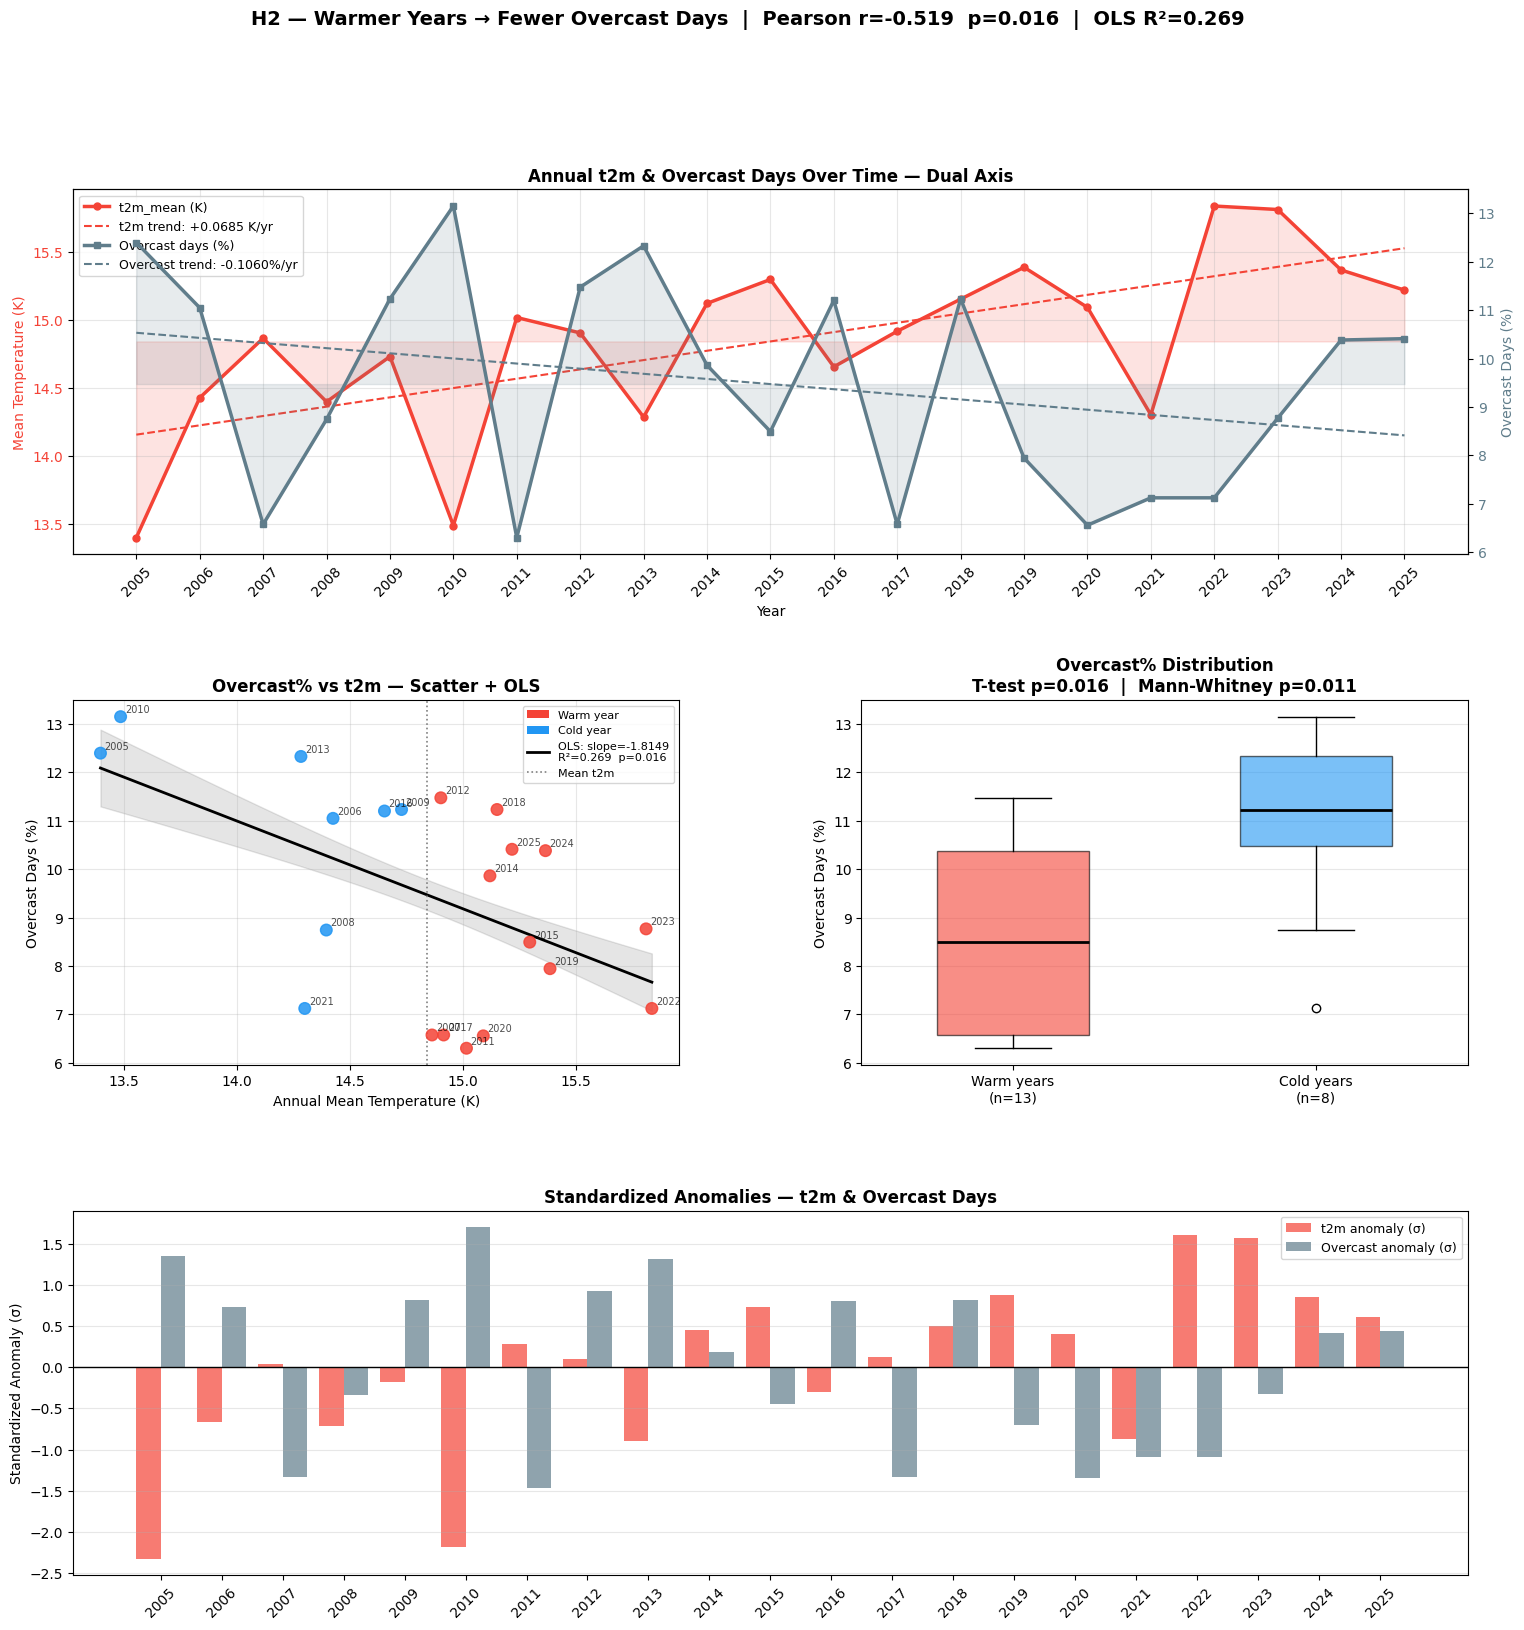

In [9]:

# ── 1. Define overcast threshold & classify years ─────────────────────────────
OVERCAST_THRESHOLD = 0.3

df_daily['is_overcast'] = df_daily['Kt_daily'] < OVERCAST_THRESHOLD

annual = (
    df_daily.groupby('year')
    .agg(
        t2m_mean      = ('t2m_mean',    'mean'),
        total_days    = ('Kt_daily',    'count'),
        overcast_days = ('is_overcast', 'sum'),
    )
    .assign(
        overcast_pct  = lambda x: (x['overcast_days'] / x['total_days'] * 100).round(3),
        is_warm_year  = lambda x: x['t2m_mean'] > x['t2m_mean'].mean(),
    )
    .round(4)
)

years    = annual.index.values
t2m      = annual['t2m_mean'].values
oc_pct   = annual['overcast_pct'].values

print("=== H2: OVERCAST DAYS PER YEAR ===")
print(f"  Overcast threshold : Kt < {OVERCAST_THRESHOLD}")
print(f"  Overall mean t2m   : {annual['t2m_mean'].mean():.4f} K\n")
print(annual.to_string())

# ── 2. Split warm vs cold years ───────────────────────────────────────────────
warm_years = annual[annual['is_warm_year']]
cold_years = annual[~annual['is_warm_year']]

print(f"\n=== WARM vs COLD YEARS SPLIT ===")
print(f"  Warm years (above mean t2m): {len(warm_years)}  → mean overcast%: {warm_years['overcast_pct'].mean():.2f}%")
print(f"  Cold years (below mean t2m): {len(cold_years)}  → mean overcast%: {cold_years['overcast_pct'].mean():.2f}%")

# ── 3. Statistical tests ──────────────────────────────────────────────────────
# T-test
t_stat, t_p = stats.ttest_ind(warm_years['overcast_pct'], cold_years['overcast_pct'])

# Mann-Whitney U (non-parametric)
u_stat, u_p = stats.mannwhitneyu(warm_years['overcast_pct'], cold_years['overcast_pct'],
                                  alternative='less')  # warm → fewer overcast

# Linear regression: overcast_pct ~ t2m
slope, intercept, r, p_reg, se = stats.linregress(t2m, oc_pct)

# Pearson & Spearman
pearson_r,  pearson_p  = stats.pearsonr(t2m, oc_pct)
spearman_r, spearman_p = stats.spearmanr(t2m, oc_pct)

print(f"\n=== STATISTICAL TESTS ===")
print(f"  T-test (warm vs cold)     : t={t_stat:+.4f}  p={t_p:.4f}  {'⚠️  Significant' if t_p  < 0.05 else '✅  Not significant'}")
print(f"  Mann-Whitney U            : u={u_stat:.1f}    p={u_p:.4f}  {'⚠️  Significant' if u_p  < 0.05 else '✅  Not significant'}")
print(f"  OLS overcast% ~ t2m       : slope={slope:+.4f}  R²={r**2:.4f}  p={p_reg:.4f}")
print(f"  Pearson  r={pearson_r:+.4f}  p={pearson_p:.4f}")
print(f"  Spearman r={spearman_r:+.4f}  p={spearman_p:.4f}")

# ── 4. Interpretation ─────────────────────────────────────────────────────────
print(f"\n=== INTERPRETATION ===")
supports = slope < 0 and p_reg < 0.05
print(f"  H2 {'supports' if supports else 'does not support'} the hypothesis.")
if supports:
    delta_t   = t2m.max() - t2m.min()
    delta_oc  = slope * delta_t
    print(f"  Over the observed t2m range (+{delta_t:.2f} K),")
    print(f"  overcast days decreased by ~{abs(delta_oc):.2f}% ({abs(delta_oc)/oc_pct.mean()*100:.1f}% of mean)")

# ── 5. Plots ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# ── 5.1 Dual axis: t2m and overcast% over time ────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
color_t  = '#f44336'
color_oc = '#607D8B'

ax1.plot(years, t2m,    color=color_t,  lw=2.5, marker='o', markersize=5, label='t2m_mean (K)')
ax1.fill_between(years, t2m, t2m.mean(), alpha=0.15, color=color_t)
s_t, i_t, _, _, _ = stats.linregress(years, t2m)
ax1.plot(years, i_t + s_t * years, color=color_t, lw=1.5, linestyle='--',
         label=f't2m trend: {s_t:+.4f} K/yr')

ax2 = ax1.twinx()
ax2.plot(years, oc_pct, color=color_oc, lw=2.5, marker='s', markersize=5, label='Overcast days (%)')
ax2.fill_between(years, oc_pct, oc_pct.mean(), alpha=0.15, color=color_oc)
s_oc, i_oc, _, _, _ = stats.linregress(years, oc_pct)
ax2.plot(years, i_oc + s_oc * years, color=color_oc, lw=1.5, linestyle='--',
         label=f'Overcast trend: {s_oc:+.4f}%/yr')

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Temperature (K)', color=color_t)
ax2.set_ylabel('Overcast Days (%)', color=color_oc)
ax1.tick_params(axis='y', labelcolor=color_t)
ax2.tick_params(axis='y', labelcolor=color_oc)
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)
ax1.set_title('Annual t2m & Overcast Days Over Time — Dual Axis', fontsize=12, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# ── 5.2 Scatter: overcast% vs t2m ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_scatter = [color_t if w else '#2196F3' for w in annual['is_warm_year']]
ax3.scatter(t2m, oc_pct, c=colors_scatter, alpha=0.85, s=70, zorder=3)

x_fit = np.linspace(t2m.min(), t2m.max(), 200)
y_fit = intercept + slope * x_fit
t_crit = stats.t.ppf(0.975, df=len(t2m) - 2)
y_err  = t_crit * se * np.sqrt(1/len(t2m) + (x_fit - t2m.mean())**2 / np.sum((t2m - t2m.mean())**2))

ax3.plot(x_fit, y_fit, color='black', lw=2,
         label=f'OLS: slope={slope:+.4f}\nR²={r**2:.3f}  p={p_reg:.3f}')
ax3.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color='black', alpha=0.1, label='95% CI')

for yr, tx, ox in zip(years, t2m, oc_pct):
    ax3.annotate(str(yr), (tx, ox), fontsize=7, alpha=0.7,
                 xytext=(3, 3), textcoords='offset points')

ax3.axvline(t2m.mean(), color='grey', lw=1.2, linestyle=':', label='Mean t2m')
ax3.set_xlabel('Annual Mean Temperature (K)')
ax3.set_ylabel('Overcast Days (%)')
ax3.set_title('Overcast% vs t2m — Scatter + OLS', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_t,   label='Warm year'),
                   Patch(facecolor='#2196F3',  label='Cold year')]
ax3.legend(handles=legend_elements + ax3.get_lines(), fontsize=8)
ax3.grid(True, alpha=0.3)

# ── 5.3 Boxplot: warm vs cold years ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bp = ax4.boxplot(
    [warm_years['overcast_pct'].values, cold_years['overcast_pct'].values],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor(color_t)
bp['boxes'][1].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_alpha(0.6)

ax4.set_xticks([1, 2])
ax4.set_xticklabels([f'Warm years\n(n={len(warm_years)})', f'Cold years\n(n={len(cold_years)})'])
ax4.set_ylabel('Overcast Days (%)')
ax4.set_title(f'Overcast% Distribution\nT-test p={t_p:.3f}  |  Mann-Whitney p={u_p:.3f}',
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# ── 5.4 Standardized anomalies ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
t2m_anom = (t2m   - t2m.mean())   / t2m.std()
oc_anom  = (oc_pct - oc_pct.mean()) / oc_pct.std()

ax5.bar(years - 0.2, t2m_anom, width=0.4, color=color_t,  alpha=0.7, label='t2m anomaly (σ)')
ax5.bar(years + 0.2, oc_anom,  width=0.4, color=color_oc, alpha=0.7, label='Overcast anomaly (σ)')
ax5.axhline(0, color='black', lw=1)
ax5.set_xticks(years)
ax5.set_xticklabels(years, rotation=45)
ax5.set_ylabel('Standardized Anomaly (σ)')
ax5.set_title('Standardized Anomalies — t2m & Overcast Days', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'H2 — Warmer Years → Fewer Overcast Days  |  Pearson r={pearson_r:+.3f}  p={pearson_p:.3f}  |  OLS R²={r**2:.3f}',
    fontsize=14, fontweight='bold'
)
plt.show()

# ── Clean up ──────────────────────────────────────────────────────────────────
df_daily = df_daily.drop(columns='is_overcast')

### H3 - Warmer years show lower GHI intraday variability 

=== H4: GHI INTRADAY VARIABILITY PER YEAR ===
  Overall mean t2m     : 14.8390 K
  Warm years (n=13)    : mean GHI_var = 53191.231
  Cold years (n=8)    : mean GHI_var = 50919.237

      t2m_mean  ghi_var_mean  ghi_var_med  ghi_var_std  is_warm_year
year                                                                
2005   13.3969    51187.4473   43402.9122   38552.9843         False
2006   14.4249    52525.7031   48731.6608   37070.8556         False
2007   14.8625    53537.9390   47946.0130   39090.1253          True
2008   14.3952    50343.2695   41803.0535   37814.6344         False
2009   14.7279    51033.9121   46714.5126   38874.0348         False
2010   13.4859    48978.8756   40872.9858   40187.5706         False
2011   15.0149    55861.3515   55756.7561   38619.5465          True
2012   14.9016    54202.7860   46605.9769   39376.6590          True
2013   14.2830    50572.6391   39940.3017   40285.4458         False
2014   15.1186    49169.1025   42379.8694   38448.8512      

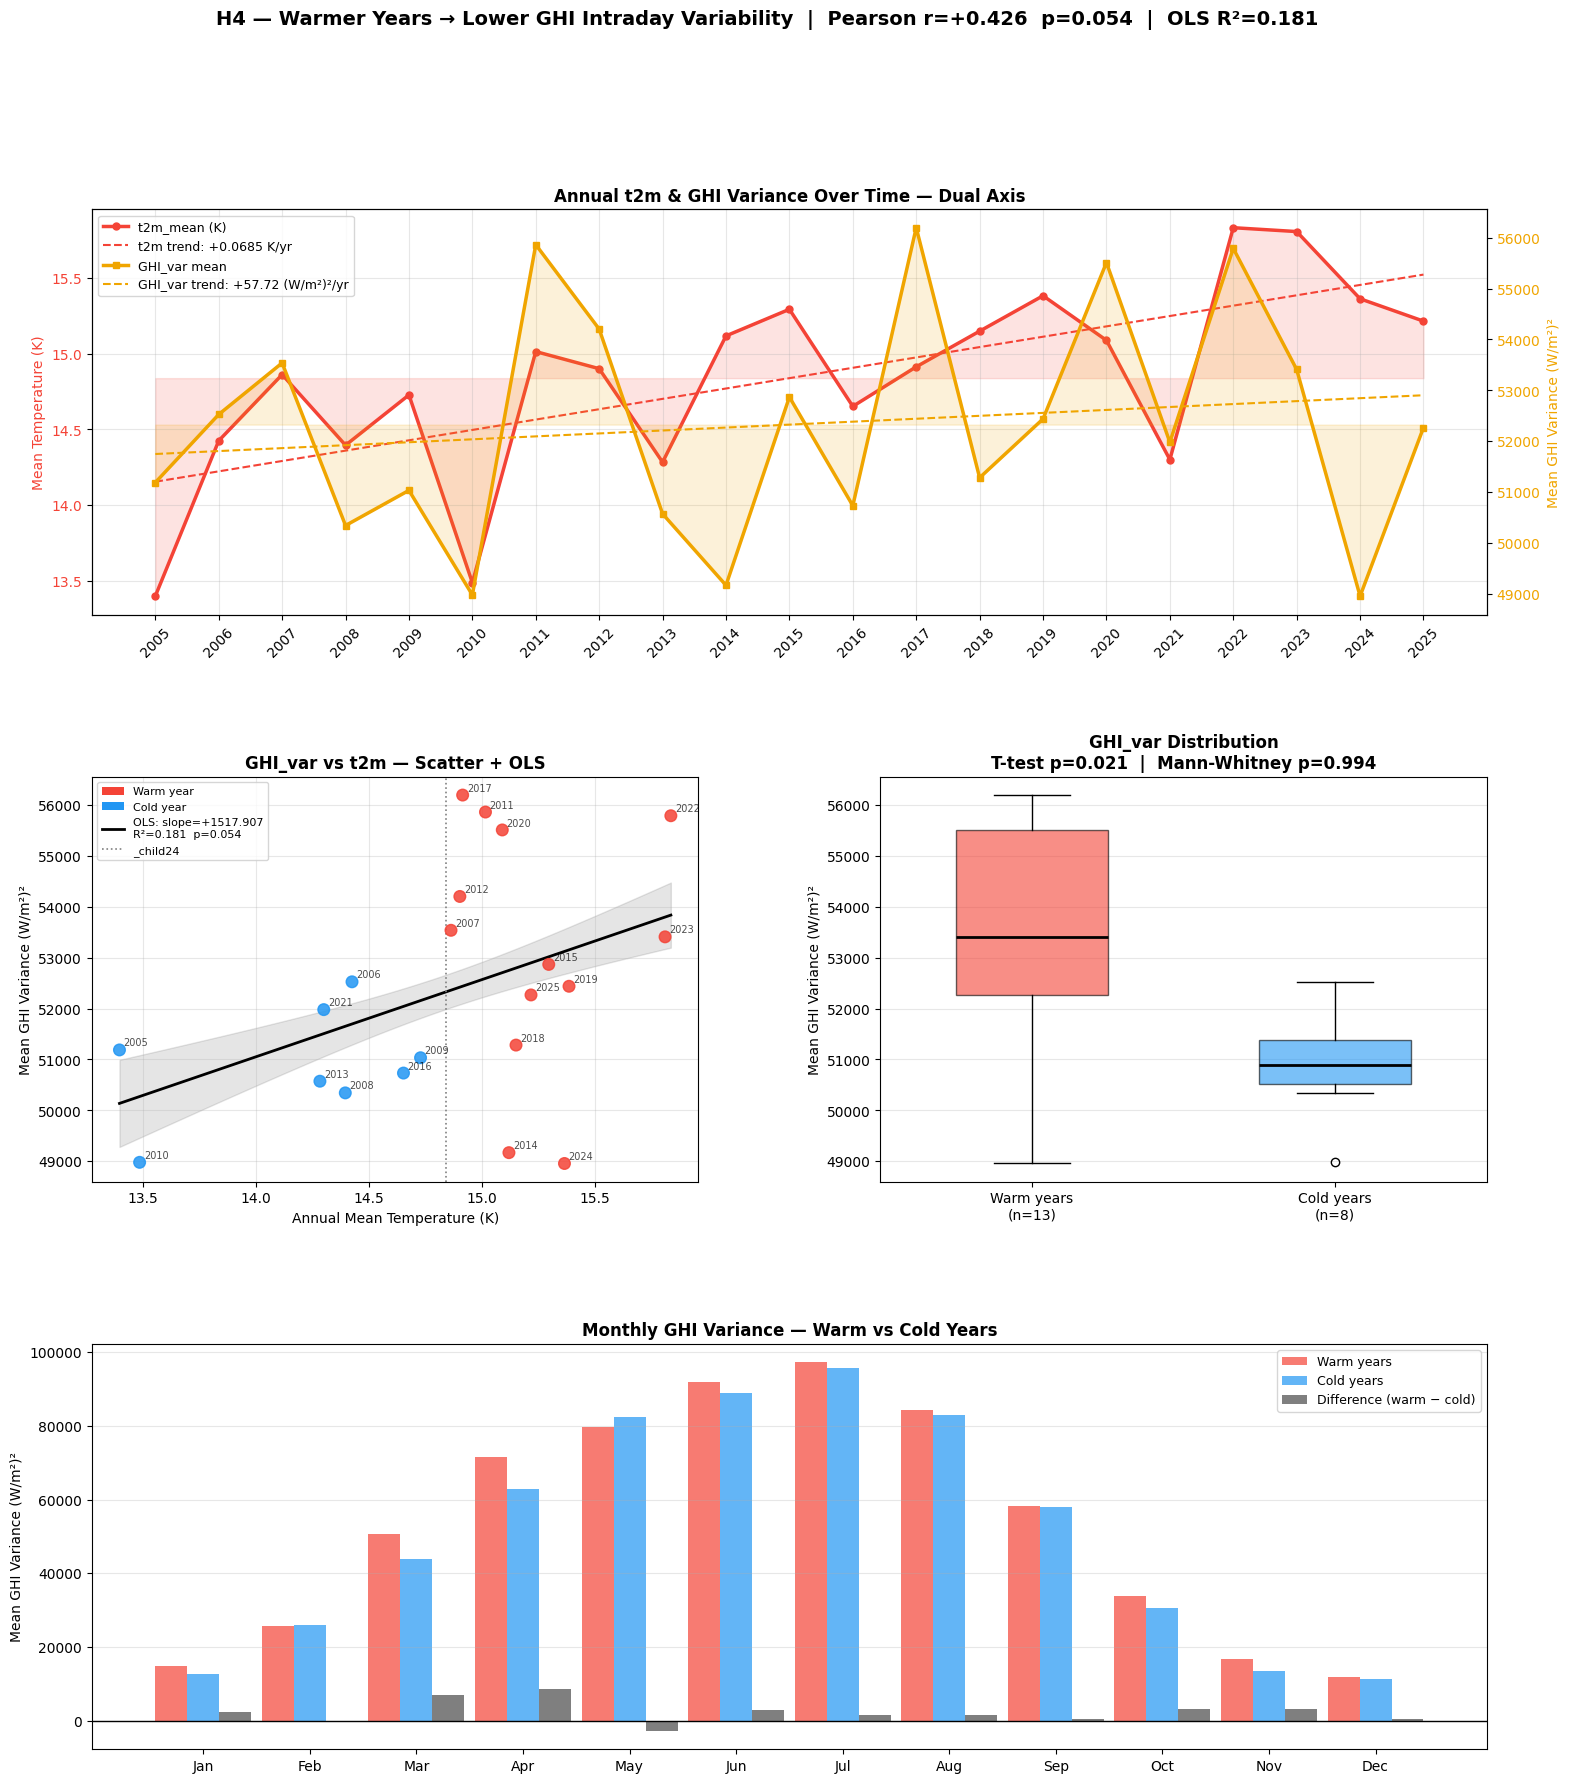

In [13]:

# ── 1. Annual aggregation ─────────────────────────────────────────────────────
annual = (
    df_daily.groupby('year')
    .agg(
        t2m_mean    = ('t2m_mean', 'mean'),
        ghi_var_mean= ('GHI_var',  'mean'),
        ghi_var_med = ('GHI_var',  'median'),
        ghi_var_std = ('GHI_var',  'std'),
    )
    .assign(is_warm_year = lambda x: x['t2m_mean'] > x['t2m_mean'].mean())
    .round(4)
)

years      = annual.index.values
t2m        = annual['t2m_mean'].values
ghi_var    = annual['ghi_var_mean'].values
warm_years = annual[annual['is_warm_year']]
cold_years = annual[~annual['is_warm_year']]

print("=== H4: GHI INTRADAY VARIABILITY PER YEAR ===")
print(f"  Overall mean t2m     : {annual['t2m_mean'].mean():.4f} K")
print(f"  Warm years (n={len(warm_years)})    : mean GHI_var = {warm_years['ghi_var_mean'].mean():.3f}")
print(f"  Cold years (n={len(cold_years)})    : mean GHI_var = {cold_years['ghi_var_mean'].mean():.3f}\n")
print(annual.to_string())

# ── 2. Statistical tests ──────────────────────────────────────────────────────
# Linear regression: GHI_var ~ t2m
slope, intercept, r, p_reg, se = stats.linregress(t2m, ghi_var)

# Pearson & Spearman
pearson_r,  pearson_p  = stats.pearsonr(t2m,  ghi_var)
spearman_r, spearman_p = stats.spearmanr(t2m, ghi_var)

# T-test & Mann-Whitney (one-sided: warm → lower variance)
t_stat, t_p = stats.ttest_ind(warm_years['ghi_var_mean'], cold_years['ghi_var_mean'])
u_stat, u_p = stats.mannwhitneyu(warm_years['ghi_var_mean'], cold_years['ghi_var_mean'],
                                  alternative='less')

# Mann-Kendall on GHI_var over time
try:
    mk_var = mk.original_test(ghi_var)
    mk_t2m = mk.original_test(t2m)
    print(f"\n=== MANN-KENDALL TREND TEST ===")
    print(f"  GHI_var : trend={mk_var.trend:<12} | tau={mk_var.Tau:.4f} | p={mk_var.p:.4f} | slope={mk_var.slope:+.4f}")
    print(f"  t2m     : trend={mk_t2m.trend:<12} | tau={mk_t2m.Tau:.4f} | p={mk_t2m.p:.4f} | slope={mk_t2m.slope:+.4f}")
except ImportError:
    print("\n  ⚠️  pymannkendall not installed — run: pip install pymannkendall")

print(f"\n=== STATISTICAL TESTS ===")
print(f"  OLS GHI_var ~ t2m   : slope={slope:+.4f}  R²={r**2:.4f}  p={p_reg:.4f}  {'⚠️  Significant' if p_reg < 0.05 else '✅  Not significant'}")
print(f"  Pearson  r={pearson_r:+.4f}  p={pearson_p:.4f}")
print(f"  Spearman r={spearman_r:+.4f}  p={spearman_p:.4f}")
print(f"  T-test (warm vs cold)     : t={t_stat:+.4f}  p={t_p:.4f}  {'⚠️  Significant' if t_p  < 0.05 else '✅  Not significant'}")
print(f"  Mann-Whitney U (one-sided): u={u_stat:.1f}    p={u_p:.4f}  {'⚠️  Significant' if u_p  < 0.05 else '✅  Not significant'}")

# ── 3. Interpretation ─────────────────────────────────────────────────────────
print(f"\n=== INTERPRETATION ===")
supports = slope < 0 and p_reg < 0.05
print(f"  H4 {'supports' if supports else 'does not support'} the hypothesis.")
if supports:
    delta_t   = t2m.max() - t2m.min()
    delta_var = slope * delta_t
    print(f"  Over the observed t2m range (+{delta_t:.2f} K),")
    print(f"  GHI_var decreased by ~{abs(delta_var):.2f} (W/m²)²  ({abs(delta_var)/ghi_var.mean()*100:.1f}% of mean)")

# ── 4. Plots ──────────────────────────────────────────────────────────────────

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

color_t   = '#f44336'
color_var = '#f0a500'

# ── 4.1 Dual axis: t2m and GHI_var over time ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(years, t2m, color=color_t, lw=2.5, marker='o', markersize=5, label='t2m_mean (K)')
ax1.fill_between(years, t2m, t2m.mean(), alpha=0.15, color=color_t)
s_t, i_t, _, _, _ = stats.linregress(years, t2m)
ax1.plot(years, i_t + s_t * years, color=color_t, lw=1.5, linestyle='--',
         label=f't2m trend: {s_t:+.4f} K/yr')

ax2 = ax1.twinx()
ax2.plot(years, ghi_var, color=color_var, lw=2.5, marker='s', markersize=5, label='GHI_var mean')
ax2.fill_between(years, ghi_var, ghi_var.mean(), alpha=0.15, color=color_var)
s_v, i_v, _, _, _ = stats.linregress(years, ghi_var)
ax2.plot(years, i_v + s_v * years, color=color_var, lw=1.5, linestyle='--',
         label=f'GHI_var trend: {s_v:+.2f} (W/m²)²/yr')

ax1.set_ylabel('Mean Temperature (K)', color=color_t)
ax2.set_ylabel('Mean GHI Variance (W/m²)²', color=color_var)
ax1.tick_params(axis='y', labelcolor=color_t)
ax2.tick_params(axis='y', labelcolor=color_var)
ax1.set_xticks(years)
ax1.set_xticklabels(years, rotation=45)
ax1.set_title('Annual t2m & GHI Variance Over Time — Dual Axis', fontsize=12, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# ── 4.2 Scatter: GHI_var vs t2m ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_scatter = [color_t if w else '#2196F3' for w in annual['is_warm_year']]
ax3.scatter(t2m, ghi_var, c=colors_scatter, alpha=0.85, s=70, zorder=3)

x_fit  = np.linspace(t2m.min(), t2m.max(), 200)
y_fit  = intercept + slope * x_fit
t_crit = stats.t.ppf(0.975, df=len(t2m) - 2)
y_err  = t_crit * se * np.sqrt(1/len(t2m) + (x_fit - t2m.mean())**2 / np.sum((t2m - t2m.mean())**2))

ax3.plot(x_fit, y_fit, color='black', lw=2,
         label=f'OLS: slope={slope:+.3f}\nR²={r**2:.3f}  p={p_reg:.3f}')
ax3.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color='black', alpha=0.1, label='95% CI')

for yr, tx, vx in zip(years, t2m, ghi_var):
    ax3.annotate(str(yr), (tx, vx), fontsize=7, alpha=0.7,
                 xytext=(3, 3), textcoords='offset points')

ax3.axvline(t2m.mean(), color='grey', lw=1.2, linestyle=':')
ax3.set_xlabel('Annual Mean Temperature (K)')
ax3.set_ylabel('Mean GHI Variance (W/m²)²')
ax3.set_title('GHI_var vs t2m — Scatter + OLS', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_t,  label='Warm year'),
                   Patch(facecolor='#2196F3', label='Cold year')]
ax3.legend(handles=legend_elements + ax3.get_lines(), fontsize=8)
ax3.grid(True, alpha=0.3)

# ── 4.3 Boxplot: warm vs cold years ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bp  = ax4.boxplot(
    [warm_years['ghi_var_mean'].values, cold_years['ghi_var_mean'].values],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor(color_t)
bp['boxes'][1].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_alpha(0.6)

ax4.set_xticks([1, 2])
ax4.set_xticklabels([f'Warm years\n(n={len(warm_years)})', f'Cold years\n(n={len(cold_years)})'])
ax4.set_ylabel('Mean GHI Variance (W/m²)²')
ax4.set_title(f'GHI_var Distribution\nT-test p={t_p:.3f}  |  Mann-Whitney p={u_p:.3f}',
              fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# ── 4.4 Monthly GHI_var: warm vs cold years heatmap ──────────────────────────
ax5 = fig.add_subplot(gs[2, :])
df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month
df_daily['is_warm_year'] = df_daily['year'].map(annual['is_warm_year'])

monthly_warm = (df_daily[df_daily['is_warm_year']]
                .groupby('month')['GHI_var'].mean())
monthly_cold = (df_daily[~df_daily['is_warm_year']]
                .groupby('month')['GHI_var'].mean())
monthly_diff = monthly_warm - monthly_cold

x = np.arange(1, 13)
w = 0.3
ax5.bar(x - w, monthly_warm, width=w, color=color_t,   alpha=0.7, label='Warm years')
ax5.bar(x,     monthly_cold, width=w, color='#2196F3',  alpha=0.7, label='Cold years')
ax5.bar(x + w, monthly_diff, width=w, color='black',    alpha=0.5, label='Difference (warm − cold)')
ax5.axhline(0, color='black', lw=1)

ax5.set_xticks(x)
ax5.set_xticklabels(month_labels)
ax5.set_ylabel('Mean GHI Variance (W/m²)²')
ax5.set_title('Monthly GHI Variance — Warm vs Cold Years', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'H4 — Warmer Years → Lower GHI Intraday Variability  |  Pearson r={pearson_r:+.3f}  p={pearson_p:.3f}  |  OLS R²={r**2:.3f}',
    fontsize=14, fontweight='bold'
)
plt.show()

# ── Clean up ──────────────────────────────────────────────────────────────────
df_daily = df_daily.drop(columns='is_warm_year')